# 03 · A2 Djinni — the in-domain corpus

141,897 IT job descriptions and 210,250 pre-anonymized CVs from a real hiring platform,
MIT-licensed. It replaces the "200+ self-collected job descriptions" plan, which had no
lawful collection path (decision **D3**).

It carries **no fit labels**. What it does carry is a join key present on both sides —
`Primary Keyword` — which is what makes in-domain candidate pools constructible before the
team adjudicates 200 pairs by hand (decisions **D4**, **D12**).

**Question this notebook answers for the team: which role families does the in-domain set
sample from?** (open question **Q9**)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from candidate_screener.config import DOCS_DATA, RAW, MANIFEST, PROFILE_METRICS
from candidate_screener.data.profile import load_split
from candidate_screener.data.sources import SOURCES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

METRICS = json.loads(PROFILE_METRICS.read_text())["checks"]
print("profile metrics generated:", json.loads(PROFILE_METRICS.read_text())["generated"])

profile metrics generated: 2026-08-19T11:44:13+00:00


In [2]:
jd = load_split("djinni-jd", "train")
cv = load_split("djinni-cv", "train")
print(f"JDs: {len(jd):,}   CVs: {len(cv):,}")
print("JD columns:", list(jd.columns))
print("CV columns:", list(cv.columns))

JDs: 141,897   CVs: 210,250
JD columns: ['Position', 'Long Description', 'Company Name', 'Exp Years', 'Primary Keyword', 'English Level', 'Published', 'Long Description_lang', 'id', '__index_level_0__']
CV columns: ['Position', 'Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword', 'English Level', 'Experience Years', 'CV', 'CV_lang', 'id', '__index_level_0__']


## The join key works — 41 of 41 CV-side role families occur on the JD side

45 JD-side values, 41 CV-side, 41 shared, 0 CV-only


,JDs,CVs
Primary Keyword,,
JavaScript,17903,33980
Java,8712,11463
DevOps,7979,4120
.NET,7826,9388
Other,7536,5395
QA Automation,7047,5756
Marketing,6933,8984
QA,6774,25089
Node.js,6416,4896


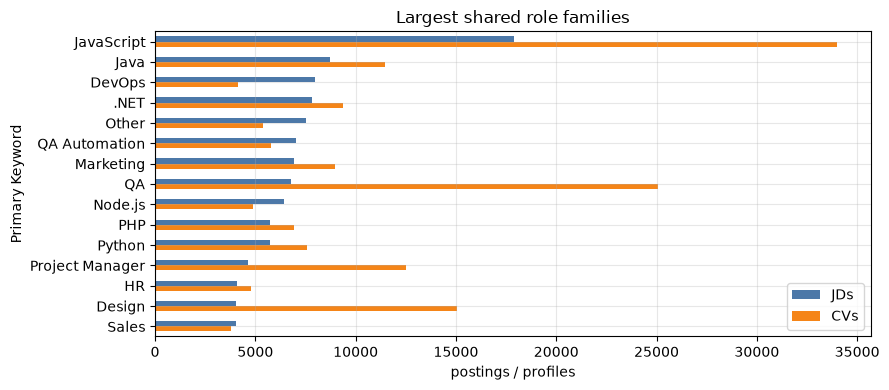

In [3]:
kj, kc = set(jd["Primary Keyword"].dropna()), set(cv["Primary Keyword"].dropna())
print(f"{len(kj)} JD-side values, {len(kc)} CV-side, {len(kj & kc)} shared, "
      f"{len(kc - kj)} CV-only")

both = pd.DataFrame({
    "JDs": jd["Primary Keyword"].value_counts(),
    "CVs": cv["Primary Keyword"].value_counts(),
}).fillna(0).astype(int).sort_values("JDs", ascending=False)
ax = both.head(15).plot.barh(color=["#4C78A8", "#F58518"])
ax.invert_yaxis(); ax.set_xlabel("postings / profiles"); ax.set_title("Largest shared role families")
plt.tight_layout(); both.head(15)

`Other`, `Marketing`, `Project Manager` and similar families are outside the
technology/data/software scope in §5.4 and are filtered out below.

In [4]:
# technology/data/software families in scope per §5.4 (open question Q9)
TECH = ["JavaScript", "Java", "Python", "DevOps", ".NET",
        "QA Automation", "Node.js", "PHP"]

scope = both.loc[[k for k in TECH if k in both.index]]
scope["CVs per JD"] = (scope.CVs / scope.JDs).round(1)
print(f"in-scope: {scope.JDs.sum():,} JDs and {scope.CVs.sum():,} CVs across {len(scope)} families")
scope

in-scope: 67,358 JDs and 84,138 CVs across 8 families


,JDs,CVs,CVs per JD
Primary Keyword,,,
JavaScript,17903,33980,1.9
Java,8712,11463,1.3
Python,5735,7588,1.3
DevOps,7979,4120,0.5
.NET,7826,9388,1.2
QA Automation,7047,5756,0.8
Node.js,6416,4896,0.8
PHP,5740,6947,1.2


Every candidate family has thousands of CVs per posting, so pool construction is not
supply-constrained anywhere — the sampling design, not availability, decides the pools.

## Banding variables — seniority and English level

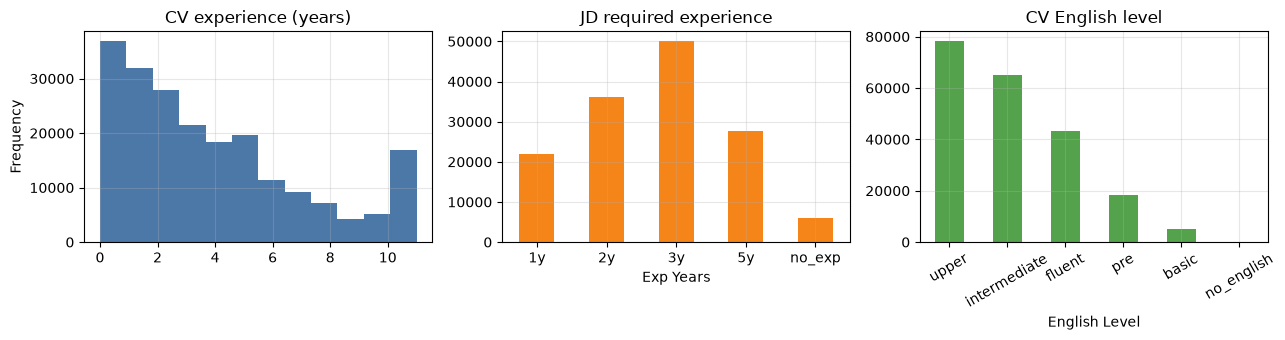

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
cv["Experience Years"].plot.hist(bins=12, ax=axes[0], color="#4C78A8", title="CV experience (years)")
jd["Exp Years"].value_counts().sort_index().plot.bar(ax=axes[1], color="#F58518",
                                                     title="JD required experience", rot=0)
cv["English Level"].value_counts().plot.bar(ax=axes[2], color="#54A24B",
                                            title="CV English level", rot=30)
plt.tight_layout()

`Experience Years` (CV, 0–11) and `Exp Years` (JD, `no_exp`/`1y`/`2y`/`3y`/`5y`) are the
banding variables for step 3 of action plan §3.4: draw ~5 candidates per JD, banded by
experience, so pools contain plausible near-misses rather than only obvious mismatches.

## Pool feasibility for the 200-pair annotation set

In [6]:
band = lambda y: "0-1" if y <= 1 else "2-3" if y <= 3 else "4-6" if y <= 6 else "7+"
pool = (cv[cv["Primary Keyword"].isin(scope.index)]
        .assign(band=lambda d: d["Experience Years"].map(band))
        .groupby(["Primary Keyword", "band"]).size().unstack(fill_value=0))
print("CVs available per (family, experience band) — every cell is a candidate pool")
pool

CVs available per (family, experience band) — every cell is a candidate pool


band,0-1,2-3,4-6,7+
Primary Keyword,,,,
.NET,2087,2299,2282,2720
DevOps,704,1140,979,1297
Java,3320,2994,2706,2443
JavaScript,12120,10385,7542,3933
Node.js,887,1548,1492,969
PHP,630,1551,2379,2387
Python,2863,2384,1464,877
QA Automation,782,1694,1805,1475


## Read one JD and one CV end to end

In [7]:
q = jd[jd["Primary Keyword"] == "Python"].iloc[0]
c = cv[cv["Primary Keyword"] == "Python"].iloc[0]
print(f"=== JD | {q.Position} | {q['Company Name']} | {q['Exp Years']} | {q['English Level']}")
print(str(q["Long Description"])[:900], "...\n")
print(f"=== CV | {c.Position} | {c['Experience Years']}y | {c['English Level']}")
print(str(c.CV)[:900], "...")

=== JD | 1815/06 Lead/Senior Backend Engineer (Python) | Argument | 3y | upper
**Требования:**
Python - 3 года
Опыт в SQL
Опыт в NoSQL
Опыт в Kubernetes
Опыт в Docker
Опыт в Methodologies
Опыт в TensorFlow
Опыт в PyTorch

**Requirements**
- 3-5+ years of experience in Python development
- B.Sc in computer science or a related field
- Worked on large-scale service oriented distributed systems
- Experience with different types of data storage (SQL, NoSQL, search engines, big data databases, object stores)
- Experience with containerization and cluster management technologies like Docker and Kubernetes
- Tech savvy - we are looking for someone who likes to learn and develop tech skills of the latest technologies and methodologies
- Experience collaborating with Research teams working with PyTorch or TensorFlow – advantage
- Good spoken and written English

**Responsibilities**
- Design & develop the infrastructure for training, deploying and monit ...

=== CV | 3d developer, C++, UE, pyth

Note the shape difference the matcher has to survive: Djinni JDs are ~1,600 chars against
A1's ~2,400, and Djinni CVs are ~750 chars — **7× shorter than A1's ~5,100-char resumes**.
A model tuned on A1 sees far less evidence per candidate here. That is a real transfer risk
and belongs in the §10 risk table alongside the market limitation (**D11**).